In [1]:
# import the necessary modules
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [2]:
basket_items = pd.read_csv("groceries_basket.csv")
basket_items.head()

,order_id,product_id,product_name,category,add_to_cart_sequence_index
0,1,49302,Bulgarian Yogurt,dairy eggs,1
1,1,10246,Organic Celery Hearts,produce,2
2,1,43633,Lightly Smoked Sardines in Olive Oil,canned goods,3
3,1,13176,Bag of Organic Bananas,produce,4
4,1,47209,Organic Hass Avocado,produce,5


In [3]:
# items
n_items = basket_items['product_id'].nunique()
print(f'Number of unique items: {n_items}')
# orders
n_orders = basket_items['order_id'].nunique()
print(f'Number of unique orders: {n_orders}')
# basket_items
n_basket_items = len(basket_items)
print(f'Number of basket items: {n_basket_items}')

Number of unique items: 26548
Number of unique orders: 64864
Number of basket items: 573124


# a) Product Frequencies

In [4]:
## Set rounding of outputs correctly
pd.set_option('display.precision', 2)
## 1. Amount of orders needed for a support of 1%
ordersOnePercent = n_orders*0.01
print("Orders needed for one percent support: More than " + str(ordersOnePercent) + "\n")

## 2. Mean support count across all products

# verify that no item appears in the same order twice
pair_counts = basket_items.value_counts(['order_id', 'product_id']).reset_index(name='count')
if not (len(pair_counts["count"].unique()) == 1 and pair_counts["count"].unique()[0] == 1):
    raise Exception("At least one item appears twice in an order")

# Generate the value counts and mean support count per product
frequencyCountProducts = basket_items["product_id"].value_counts().reset_index(name="absolute_frequency")
meansupport = frequencyCountProducts["absolute_frequency"].mean()
print("Mean support count per product:\t"+str(meansupport.__round__(2)))

## 3. Median Support count across all products
meadiansupport = frequencyCountProducts["absolute_frequency"].median()
print("Median support count per prodcut:\t" + str(meadiansupport))

Orders needed for one percent support: More than 648.64

Mean support count per product:	21.59
Median support count per prodcut:	4.0


# b) + c) Most frequent Products

You can separate these if you want, but it makes sense to do them together.

In [11]:
## Generate column of relative frequency per product
frequencyCountProducts["relative_frequency"] = frequencyCountProducts["absolute_frequency"]/n_orders

# Create a dictionary of product names
onlyOnePerProduct = basket_items.drop_duplicates(subset=["product_id"])
productNameDict = pd.Series(onlyOnePerProduct["product_name"].values,index=onlyOnePerProduct["product_id"])

## Output 10 most frequent products
sortedProductFrequency = frequencyCountProducts.sort_values("absolute_frequency", ascending=False)
print("Top 10 most frequent products:\n")
print(sortedProductFrequency[:10])

## Output the support of the third most frequent item (highest support possible for a set of three):
print("\nHighest possible support for three items:\t" + str(sortedProductFrequency["relative_frequency"][2].round(2)))

## Generate the set of the three most popular products
threeMostFrequentIDs = sortedProductFrequency["product_id"][:3]

## Filter all orders to just appearances of the three products. As all items appear only once per order, if an order number appears thrice, it contains all items
frequentProductPurchases = basket_items[basket_items["product_id"].isin(threeMostFrequentIDs)]
popularItemsPerOrder = frequentProductPurchases["order_id"].value_counts().reset_index(name="counts")
print("Count of orders with all three items:\t" + str(len(popularItemsPerOrder[popularItemsPerOrder["counts"] == 3])))
print("Orders:\t" + str(list(popularItemsPerOrder[popularItemsPerOrder["counts"] == 3]["order_id"])))

## Find the product name of the three most frequently bought products
print("\nMost frequently bought products:")
for indx, productID in enumerate(threeMostFrequentIDs):
    print(str(indx+1)+": " + str(productID) + ": "+productNameDict[productID])

Top 10 most frequent products:

   product_id  absolute_frequency  relative_frequency
0       24852                9376                0.14
1       13176                7701                0.12
2       21137                5480                0.08
3       21903                4818                0.07
4       47626                4096                0.06
5       47766                3670                0.06
6       47209                3605                0.06
7       16797                3199                0.05
8       26209                3017                0.05
9       27966                2728                0.04

Highest possible support for three items:	0.08
Count of orders with all three items:	3
Orders:	[2275990, 850056, 3218207]

Most frequently bought products:
1: 24852: Banana
2: 13176: Bag of Organic Bananas
3: 21137: Organic Strawberries


It is very unlikely that a lot of customers buy both non-organic and organic Bananas in the same purchase.

# d) + e) Product Categories

You don't really need the notebook for e)

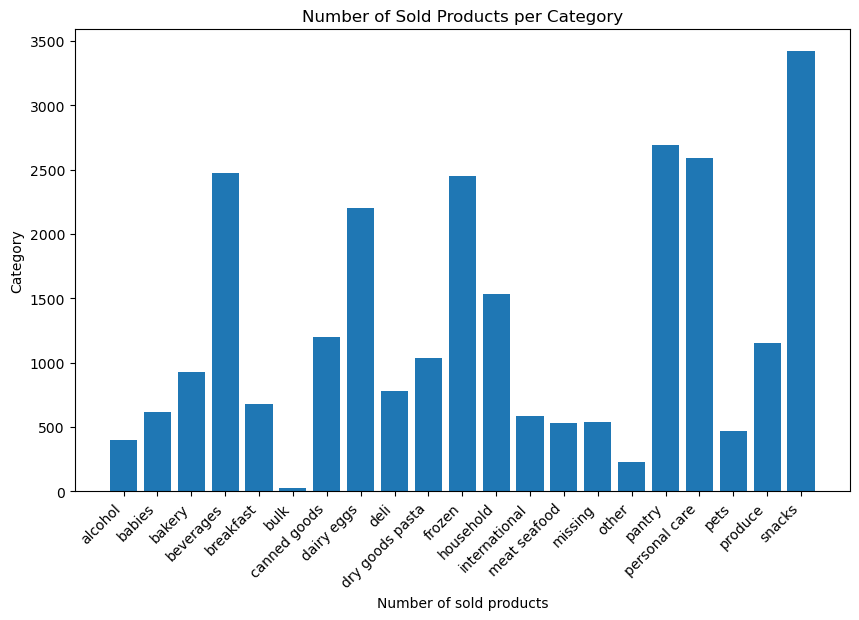

In [13]:
## Count the sold products per category
catCountDF = onlyOnePerProduct["category"].value_counts().reset_index(name="num_products").sort_values("category")

## Create the figure
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(catCountDF["category"], catCountDF["num_products"])
ax.set_title("Number of Sold Products per Category")
ax.set_xlabel("Number of sold products")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha='right')
plt.show()

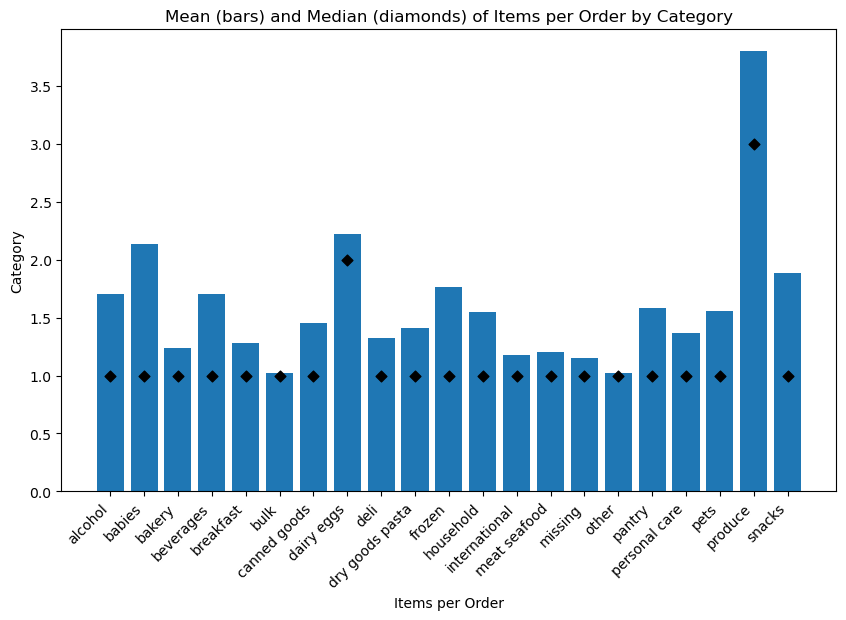

In [20]:
itemsPerCatPerOrder = basket_items.groupby(["order_id","category"]).size().groupby("category")
itemCatStats = itemsPerCatPerOrder.agg(["mean","median"]).sort_values("category", ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(itemCatStats["category"], itemCatStats["mean"])
ax.scatter(itemCatStats['category'], itemCatStats['median'], 
           color='black', s=30, zorder=5, 
           label='Median', marker='D')
ax.set_xlabel('Items per Order')
ax.set_ylabel('Category')
ax.set_title('Mean (bars) and Median (diamonds) of Items per Order by Category')
plt.xticks(rotation=45, ha='right')
plt.show()

e: Most costumers purchase one beverage per order. However, there are some orders that order significantly more beverages, bringing the average to 1.5 beverages per order.

# f) Frequent Itemsets

In [15]:
# use the provided frequent itemsets.
frequent_itemsets = pd.read_csv('frequent_itemsets.csv')
# format frozensets
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: frozenset(eval(x)))

In [27]:
## Introduce a new column correpsonding to the length of the entry itemsets and get its largest entry
frequent_itemsets["itemset_length"] = frequent_itemsets["itemsets"].apply(len)
biggest_itemset = frequent_itemsets.sort_values("itemset_length", ascending=False).iloc[0]["itemsets"]

## Print the name of each item in the itemset
print("Items in biggest itemset:")
print("Product ID, Name")
for indx, item in enumerate(biggest_itemset):
    print(str(item) + " " + str(productNameDict[item]))

## Count the itemsets size 2 or larger and print the absolute and relative count
print("\nAmount of frequent itemsets of size 2 or larger:")
countSizeTwo = len(frequent_itemsets[frequent_itemsets["itemset_length"]>=2])
print("Absolute:\t" + str(countSizeTwo))
print("Relative:\t" + str((countSizeTwo/len(frequent_itemsets)).__round__(2)))

## Create a list of frequent items by exploding the lists
frequent_items = frequent_itemsets[["itemsets", "itemset_length"]].explode("itemsets").value_counts().reset_index(name="count").sort_values("count", ascending=False)
mostFrequentItem = frequent_items["itemsets"].iloc[0]
print("\nThe most common item is: " + str(mostFrequentItem)+ " (" + productNameDict[mostFrequentItem] + ") with set count " + str(frequent_items["count"].iloc[0]))

## Print the length of all items that only feature in one set
print("\n"+str(len(frequent_items[frequent_items["count"] == 1])) + " items occurr only in a single set.")

Items in biggest itemset:
Product ID, Name
13176 Bag of Organic Bananas
47209 Organic Hass Avocado
21137 Organic Strawberries
27966 Organic Raspberries

Amount of frequent itemsets of size 2 or larger:
Absolute:	1017
Relative:	0.51

The most common item is: 24852 (Banana) with set count 138

1021 items occurr only in a single set.


# g) + h) Category Sets

You don't really need the notebook for h)

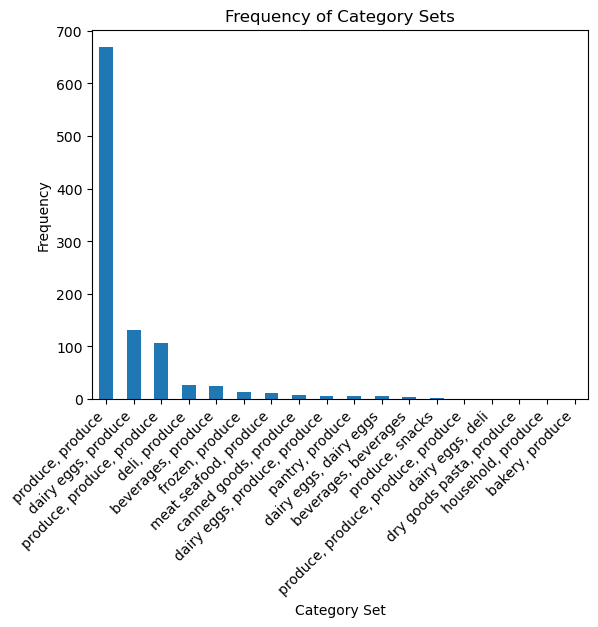

In [17]:
## Create the product category dictionary from the dataframe with only one line per product from task d and use it to create the category set
productCatDict = pd.Series(onlyOnePerProduct.category.values,index=onlyOnePerProduct.product_id).to_dict()
frequent_itemsets["category_set"] = [[productCatDict[y] for y in x] for x in frequent_itemsets["itemsets"]]
frequent_itemsets["category_set"] = frequent_itemsets["category_set"].apply(lambda x: ", ".join(sorted(list(x))))

## Filter for sets larger than two and create a Dataframe of its value counts
itemsetsTwoOrLarger = frequent_itemsets[frequent_itemsets["itemset_length"] >= 2]
category_counts = itemsetsTwoOrLarger['category_set'].value_counts().sort_values(ascending=False)

## Plot the figure using matplotlib/pandas
category_counts.plot(kind="bar")
plt.title('Frequency of Category Sets')
plt.xlabel('Category Set')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

1h: The frequency of purchases with only produce items is not unexpected as most frequently bought items from the store are of the produce category. While the amount of products offered in this category is lower, purchases have to concentrate on few items. Taking into account the broader context of human food consumption, it is also very likely that produce is the most frequently sold item, as the majority of peoples caloric intake comes from produce.

# i) Association Rules and Frequent Items

You don't really need the notebook for j)

In [18]:
# determine rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules.drop(columns=["representativity", "leverage", "conviction", "zhangs_metric", "jaccard", "certainty", "kulczynski"])
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,(47209),(13176),0.06,0.12,1.84e-02,0.33,2.79
1,(47209),(21137),0.06,0.08,1.15e-02,0.21,2.45
2,"(13176, 47209)",(21137),0.02,0.08,5.40e-03,0.29,3.47
3,"(13176, 21137)",(47209),0.02,0.06,5.40e-03,0.23,4.06
4,"(47209, 21137)",(13176),0.01,0.12,5.40e-03,0.47,3.96


In [19]:
## Filter the rules as specified in the task
rules_filtered = rules[rules["support"]*n_orders>100]
rules_filtered = rules_filtered[rules_filtered["confidence"]>0.2]

## Generate lift statistics
print("Statistics for lift:")
print(rules_filtered.lift.agg(["mean", "median"]))

## Find out association with most frequent products
# Get most frequent products from task b
tenMostFrequentIDs = sortedProductFrequency["product_id"][:10]

# Count if product is in antecedens
antecedensDF = rules_filtered.explode("antecedents")
uniqueAntecendts = antecedensDF[antecedensDF["antecedents"].isin(tenMostFrequentIDs)].index.unique()
print("\nNumber of rules with at least one of top 10 products in antecedents:\t" + str(len(uniqueAntecendts)))

# Count if product is in consequents
consequentsDF = rules_filtered.explode("consequents")
uniqueConsequents = consequentsDF[consequentsDF["consequents"].isin(tenMostFrequentIDs)].index.unique()
print("\nNumber of rules with at least one of top 10 products in consequents:\t" + str(len(uniqueConsequents)))

Statistics for lift:
mean      3.96
median    2.82
Name: lift, dtype: float64

Number of rules with at least one of top 10 products in antecedents:	222

Number of rules with at least one of top 10 products in consequents:	421


# j) Confidence

In [20]:
## Select the rule with the highest confidence
highestConfRule = rules.sort_values("confidence", ascending=False).iloc[0]

print("Rule with the highest confidence:")
print("Antecedents:\t" + str([productNameDict[x] for x in highestConfRule["antecedents"]]))
print("Consequents:\t" + str([productNameDict[x] for x in highestConfRule["consequents"]]))
print("Confidence:\t" + str(highestConfRule["confidence"].round(2)))

Rule with the highest confidence:
Antecedents:	['Organic Hass Avocado', 'Organic Strawberries', 'Organic Raspberries']
Consequents:	['Bag of Organic Bananas']
Confidence:	0.62


When a customer buys an organic avocado, organic strawberries and organic raspberries, they are very likely to also buy organic bananas (in around 62% of cases). It is not surprising to see the most frequently bought item (organic bananas) in the consequents, as it is part of a large amount of purchases. This means that it is very broadly distributed among purchases and any association of buying these bananas with other products will have less confidence.

# k) No very frequent products, Lift

In [ ]:
topTenRulesIndexes = set(uniqueAntecendts)
topTenRulesIndexes.update(set(uniqueConsequents))
topTenRulesMask = [x in topTenRulesIndexes for x in rules.index]
noTopTenRulesMask = [not x for x in topTenRulesMask]

print("Lift of rules without top ten products:")
print(rules[noTopTenRulesMask]["lift"].sort_values(ascending=False)[:10])
print("Mean lift:\t" + str(rules[noTopTenRulesMask]["lift"].mean().__round__(2)))
print("Median lift:\t" + str(rules[noTopTenRulesMask]["lift"].median().__round__(2)))

print("\nLift of rules with top ten products:")
print(rules[topTenRulesMask]["lift"].sort_values(ascending=False)[:10])
print("Mean lift:\t" + str(rules[topTenRulesMask]["lift"].mean().__round__(2)))
print("Median lift:\t" + str(rules[topTenRulesMask]["lift"].median().__round__(2)))

Lift of rules without top ten products:
Mean lift:	18.05
Median lift:	8.45

Lift of rules with top ten products:
Mean lift:	3.1
Median lift:	2.77


The lift is significantly higher for rules without the top ten products. This is not surprising as their base frequency is low, meaning the denominator in the lift equation is very small, leading to high lift. As these items are rarely purchased, any association between them are likely to result in high levels of lift.

# l) Sub-sequences

In [22]:
# function from the exercise notebook
def contained(is_seq1, is_seq2):
    size1 = len(is_seq1)
    size2 = len(is_seq2)

    if size1 > size2:
        return False

    last_1 = 0
    last_2 = 0

    while last_1 < size1 and last_2 < size2:
        item1 = is_seq1[last_1]
        item2 = is_seq2[last_2]
        if item1 == item2:
            last_1 += 1
        last_2 += 1

    if last_1 == size1:
        return True
    else:
        return False

In [33]:
## Filter only rules with one item in both antecedents and consequents with the previously filtered stats
singleAntecedentsMask = [len(x) == 1 for x in rules_filtered["antecedents"]]
singleConsequentsMask = [len(x) == 1 for x in rules_filtered["consequents"]]

signleItemRulesMask = [a and b for a, b in zip(singleAntecedentsMask, singleConsequentsMask)]
singleItemRules = rules_filtered[signleItemRulesMask]

## Go through each rule and log the indices for those that exist in the other direction too
biDirectionalRules = []
for ruleIndx in singleItemRules.index:
    rule = singleItemRules.loc[ruleIndx]
    antecedents = rule["antecedents"]
    consequents = rule["consequents"]

    conAsAntDF = singleItemRules[singleItemRules["antecedents"] == consequents]
    if antecedents in conAsAntDF["consequents"].values:
        biDirectionalRules.append(ruleIndx)

## Filter rules to unique pairs
unique_pairs = []
seen = set()
for idx in biDirectionalRules:
    rule = singleItemRules.loc[idx]
    a, b = list(rule["antecedents"])[0], list(rule["consequents"])[0]
    if tuple(sorted((a, b))) not in seen:
        unique_pairs.append((a, b))
        seen.add(tuple(sorted((a, b))))

## Ensure basked_items is sorted by order and sequence. Extract all buying sequences.
basket_sorted = basket_items.sort_values(["order_id", "add_to_cart_sequence_index"])
sequences = basket_sorted.groupby("order_id")["product_id"].apply(list)

## Count how often a follows b and b follows a
final_results = []
for a, b in unique_pairs:
    count_ab = 0
    count_ba = 0
    # Only check sequences that contain both items to save time
    for seq in sequences:
        if a in seq and b in seq:
            if contained([a, b], seq):
                count_ab += 1
            elif contained([b, a], seq):
                count_ba += 1
    
    final_results.append({"Product A": a, "Product B": b, 
                          "supportCount(a,b)": count_ab, "supportCount(b,a)": count_ba})

outputDF = pd.DataFrame(final_results)

print("Symmetrical rules with support meeting threshold:")
print(outputDF)

Symmetrical rules with support meeting threshold:
   Product A  Product B  supportCount(a,b)  supportCount(b,a)
0      13176      21137               1149                404
1      33754       4957                 57                 53
2      36865      28465                 61                 59
3      33754      33787                 69                 47


# m) Rules with support count > 99, confidence > 0.2, Lift < 1

You don't need any new calculations for this. Rather consult the lecture slides and your answer for b)

This is impossible: The most frequent item of the dataset appears in less than 20% of all purchases, so no rule can have a confidence above 0.2.